<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 3

*Alumno: Lapilli Cañedo, Mariano Adrian*

## Consigna

Diseñar un filtro pasabajos Bessel  para aproximar un Retardo de Grupo $D(\omega)$  constante en banda de paso que cumpla con la siguiente plantilla:

<img src="./consigna.png" width="500" />

<img src="./tabla.png" width="800" />

1. Utilizando el método de Storch ( pag. 403 del Schaumann ) obtener la $T(s)$ Bessel de orden N = 2, 3 y 4 

2. Elegir la T(s) con el mínimo orden que cumple con $\alpha_{MAX} = 1 dB$

3. Evaluar el Retardo de Grupo $D(2.5)$. Expresar en forma porcentual [%] el error o desviamiento respecto a $D(0)$

4. Sintetizar el circuito normalizado con estructuras Sallen-Key con K=1 ( realimentación negativa unitaria )

<img src="./sallenkey.png" width="800" />

### Bonus

Bonus:

+10 💎 Simulación numérica en python utilizando la función pretty_print_lti( num, den ) para el 1)

+10 💎 Desnormalizar los componentes para obtener un $D(0) = 200 \mu seg$

+10 💎 Simulación Circuital con los valores desnormalizados. Medir el $D(\omega)$ resultante (*) indicar con un marker el $\Delta D(\omega)$ en banda de paso.
 
(*) Para medir el  $D(\omega)$ en LTSpice, click derecho en el y Axis de la phase y seleccionar "Group Delay"

<img src="./spice.png" width="800" />

In [1]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti

### Item 1

Para obtener las expresiones de $T(s)$ mediante el método de $Storch$ vamos a necesitar las siguientes expresiones:

$T(s) = \frac{1}{senh + cosh}$

$cotgh = \frac{cosh}{senh} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{1}{\frac{7}{s} \ +\  ...}}}$

Vamos a buscar las transferencias mediante simulación simbólica:

In [2]:
s = sp.symbols("s", real = True, posistive = True) 

print_latex('Para \ orden \ 2:')

cotgh2 = ( 1 ) / ( s ) + ( 1 / ( 3 / s ) )

cotgh2 = sp.cancel(cotgh2)

num2, den2 = cotgh2.cancel().as_numer_denom()

print_latex(a_equal_b_latex_s('cotgh_2', cotgh2)) # imprimo el resultado en LaTeX

T2 = 1 / (num2 + den2)

print_latex(a_equal_b_latex_s('T_2(s)', T2)) # imprimo el resultado en LaTeX

print("----------------------------------------------------------")

print_latex('Para \ orden \ 3:')

cotgh3 = ( 1 ) / ( s ) + ( 1 / ( ( 3 / s ) + ( 1 / ( 5 / s ) ) ) )

cotgh3 = sp.cancel(cotgh3)

num3, den3 = cotgh3.cancel().as_numer_denom()

print_latex(a_equal_b_latex_s('cotgh_3', cotgh3)) # imprimo el resultado en LaTeX

T3 = 1 / (num3 + den3)

print_latex(a_equal_b_latex_s('T_3(s)', T3)) # imprimo el resultado en LaTeX

print("----------------------------------------------------------")

print_latex('Para \ orden \ 4:')

cotgh4 = ( 1 ) / ( s ) + ( 1 / ( ( 3 / s ) + ( 1 / ( ( 5 / s ) + 1 / ( 7/s ) ) ) ) )

cotgh4 = sp.cancel(cotgh4)

num4, den4 = cotgh4.cancel().as_numer_denom()

print_latex(a_equal_b_latex_s('cotgh_4', cotgh4)) # imprimo el resultado en LaTeX

T4 = 1 / (num4 + den4)

print_latex(a_equal_b_latex_s('T_4(s)', T4)) # imprimo el resultado en LaTeX


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

----------------------------------------------------------


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

----------------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Los resultados de la simulación simbólica son correctos, pero nos falta agregar el término independiente en los numeradores de cada transferencia para poder tener una transferencia pasa bajo real:

$ T_2(s) = \frac{3}{s^{2} + 3s + 3} $

$ T_3(s) = \frac{15}{s^{3}+ 6s^{2} + 15s + 15} $

$ T_4(s) = \frac{105}{s^{3} + 10s^{3} + 45s^{2} + 105s + 105} $

## Item 2

Vamos nuevamente a obtener los valores de $ \frac{1}{|T(1)|} $

$ |T_2(j\omega)| = \frac{3}{\sqrt{ (3\omega)^{2} + (3-\omega^{2})^{2}}} \rightarrow |T(1)| = 0.8321 \rightarrow \frac{1}{|T(1)|} = 1.2018 = 1.5965 dB \ \times $

$ |T_3(j\omega)| = \frac{15}{\sqrt{ (15\omega - 1 )^{2} + (15-6\omega^{2})^{2}}} \rightarrow |T(1)| = 0.9013 \rightarrow \frac{1}{|T(1)|} = 1.1095 = 0.9026 dB \ \checkmark$

$ |T_4(j\omega)| = \frac{105}{\sqrt{ (105\omega - 10 )^{2} + (105 - 45\omega^{2} + 1)^{2}}} \rightarrow |T(1)| = 0.93 \rightarrow \frac{1}{|T(1)|} = 1.0753 = 0.6303 dB \ \times $

Me quedó con el filtro de orden 3, porque es el que mejor cumple la condición de $\alpha_{MAX} = 1 dB$

$$ T_3(s) = \frac{15}{s^{3}+ 6s^{2} + 15s + 15} $$

## Item 3

Buscamos los polos de la transferencia $Bessel$ obtenida del inciso anterior:


/home/mariano/marianoTC2/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


array([-1.83890732+1.75438096j, -1.83890732-1.75438096j,
       -2.32218535+0.j        ])

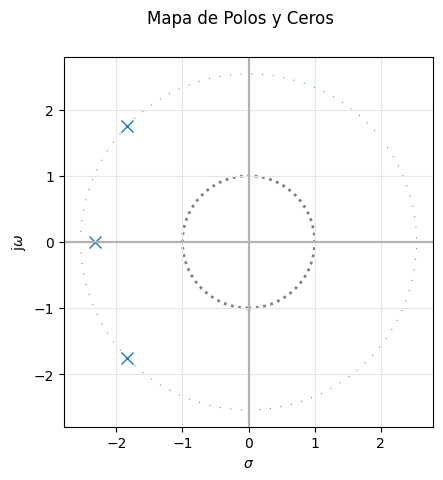

In [3]:
#Busco polos y ceros y defino numericamente los polos de la transferencia

num = [0, 15]

den = [1, 6, 15, 15]

H = sig.TransferFunction(num, den)

pzmap(H)

plt.show

np.roots(den)

Ya obtuvimos los polos de nuestro sistema Pasa Bajo y son:

$ s = -1.8389 \pm \ j \ 1.7544 $

$ s = -2.3222  $

Sabiendo que la expresión del retardo de grupo $D(\omega)$ es:

$$D(\omega) = -\sum \frac{\sigma_i}{\sigma_{i}^2 + (\omega - \omega_{i})^{2}} + \sum \frac{\sigma_j}{\sigma_{j}^2 + (\omega - \omega_{j})^{2}}$$

Siendo los términos sub i los retardos generados por los ceros (efecto negativo) y los términos sub j los retardos generados por los polos (efecto positivo). En este caso como no tenemos ceros explícitos, la expresión del retardo de grupo $D(\omega)$ queda de la siguiente forma:

$$D(\omega) = \frac{2.3222}{2.3222^2 + \omega^{2}} + \frac{1.8389}{1.8389^2 + (\omega - 1.7544)^{2}} + \frac{1.8389}{1.8389^2 + (\omega + 1.7544)^{2}}$$

Vamos a evaluar el retardo en $D(2.5)$:

In [4]:
print_latex('Evaluo \ D(2.5):')

Dd = ( 2.3222 ) / ( 2.3222**2 + 2.5**2 ) + ( 1.8389 ) / ( 1.8389**2  + ( 2.5 - 1.7544 ) )**2 + ( 1.8389 ) / ( 1.8389**2  + ( 2.5 + 1.7544 )**2 )

Dd_sympy = sp.Float(Dd, 5)

print_latex(a_equal_b_latex_s('D(2.5)', Dd_sympy))

print('--------------------------------------------------------')

print_latex('Evaluo \ D(0):')

Dc = ( 2.3222 ) / ( 2.3222**2 ) + ( 1.8389 ) / ( 1.8389**2  + ( - 1.7544 )**2 ) + ( 1.8389 ) / ( 1.8389**2  + ( 1.7544 )**2 )

Dc_sympy = sp.Float(Dc, 5)

print_latex(a_equal_b_latex_s('D(0)', Dc_sympy))

print('--------------------------------------------------------')

print_latex('Evaluo \ D(0) - D(2.5):')

Ds = Dc - Dd

Ds = Ds * 100

Ds_sympy = sp.Float(Ds, 5)

print_latex(a_equal_b_latex_s('Desvío', f"{sp.latex(Ds_sympy)}\\%"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

--------------------------------------------------------


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Item 4

Para este item, nuevamente vamos a hacer uso de la simulación simbolica para factorizar la transferencia del Item 1:


In [5]:
#Simulación simbólica de Transferencia Bessel de orden 3

w = sp.symbols("s", real = True, posistive = True) 

a1 = 2.32218535

a2 = 1.83890732

b2 = 1.75438096

mod2 = (a2**2 + b2**2)

H1 = a1 / (a1 + w)

H2 = mod2 / (w**2 + 2 * a2 * w + mod2)

T = H1 * H2

Ts = sp.expand(T)

print_latex(a_equal_b_latex_s('T(s)', f"{sp.latex(H1) + sp.latex(H2)} = {sp.latex(Ts)}"))



<IPython.core.display.Math object>

Esto sabiendo que la estrcuctura genérica de un pasa bajo de primer orden es:

$T(s) = \frac{\sigma}{s + \sigma}$

$T(s) = \frac{(\sigma^{2} + \omega_i^{2})}{s^{2} + 2 \ \sigma \ s + (\sigma^{2} + \omega_i^{2})}$

Síntesis hecha en pizarra:

<img src="./sintesis.jpg" align="center" width=800 />

## Items Bonus

Simulación númerica en Python:

In [6]:
#simulacion simbolica

num = [15]

den = [1, 6, 15, 15]

pretty_print_lti(num, den)


<IPython.core.display.Math object>

Si quiero desnormalizar para tener un retardo de $200\mu s$ tengo que multiplicar a la variable de Laplace s por el nuevo retardo que quiero lograr:

$s = \frac{s}{\frac{1}{D}}$

Mediante simulación simbolica vamos a llegar a esta nueva transferencia:

In [7]:
s = sp.symbols("s", real = True, posistive = True) 

s = (s * 200e-6)

T = 15 / (s**3 + 6 * s**2  + 15 * s +15 ) 

denominador = sp.denom(T).expand()
coef_principal = sp.Poly(denominador, s).LC()  # Esto agarra el 8.0e-12

num_monic = (sp.numer(T) / coef_principal).evalf(6)
den_monic = (denominador / coef_principal).expand().evalf(6)

Ts = num_monic / den_monic

Ts = Ts.cancel()

print_latex(a_equal_b_latex_s('T(s)', Ts))

<IPython.core.display.Math object>

In [71]:
# Importé este código que le pedí a Gemini, no sabía como dejarlo mónico

s = sp.symbols("s", real=True, positive=True)

# 1. Tu definición original (ojo que la segunda línea pisa a la s original)
s_desnormalizada = s * 200e-6
T = 15 / (s_desnormalizada**3 + 6 * s_desnormalizada**2 + 15 * s_desnormalizada + 15)

# 2. Buscamos el denominador y el coeficiente de s^3 (el coeficiente principal)
denominador = sp.denom(T).expand()
coef_principal = sp.Poly(denominador, s).LC()  # Esto agarra el 8.0e-12

# 3. Dividimos tanto numerador como denominador por ese coeficiente
num_monic = (sp.numer(T) / coef_principal).evalf(6)
den_monic = (denominador / coef_principal).expand().evalf(6)

# 4. Armamos la nueva transferencia mónica
Ts = num_monic / den_monic

# 5. Imprimimos el resultado impecable
print_latex(a_equal_b_latex_s('T(s)', Ts))

<IPython.core.display.Math object>

array([ -9194.53661343+8771.90479892j,  -9194.53661343-8771.90479892j,
       -11610.92677313   +0.j        ])

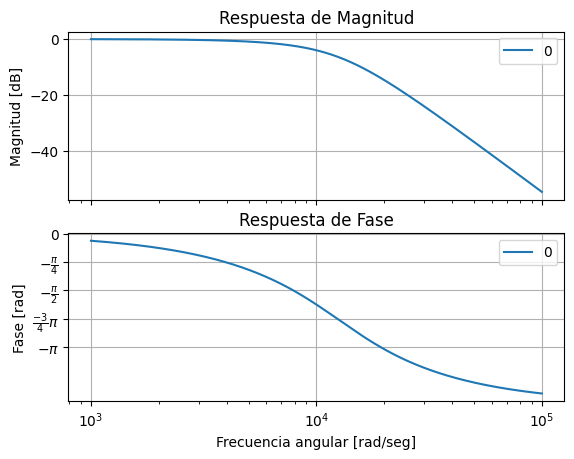

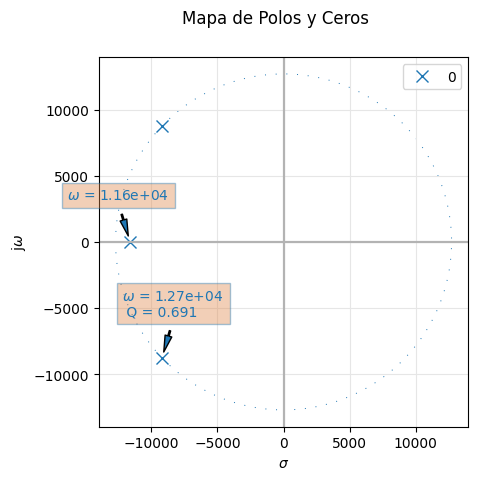

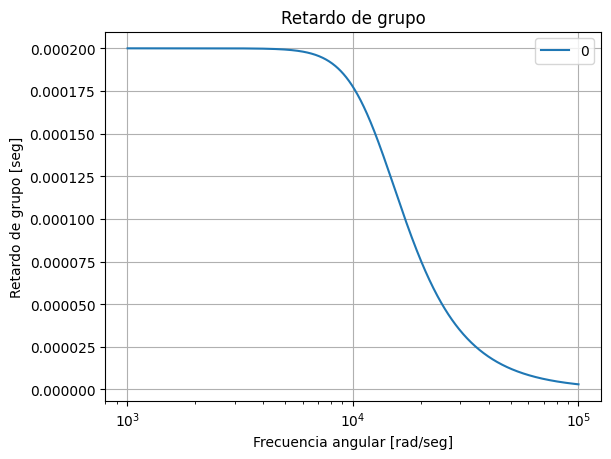

In [72]:
# Simulo retardo de fase para verificar

num = [0, 1.875e12]

den = [1, 30000, 3.75e8, 1.875e12]

H = sig.TransferFunction(num, den)

_ = analyze_sys(H)

plt.show

np.roots(den)

### Conclusión: verifica 

In [73]:
# Armo la transferencia desnormalizada

w = sp.symbols("s", real = True, posistive = True) 

a1 = 11610.92677313

a2 = 9194.53661343

b2 = 8771.90479892

mod2 = (a2**2 + b2**2)

H1 = a1 / (a1 + w)

H2 = mod2 / (w**2 + 2 * a2 * w + mod2)

T = H1 * H2

Ts = sp.expand(T)

print_latex(a_equal_b_latex_s('T(s)', f"{sp.latex(H1) + sp.latex(H2)} = {sp.latex(Ts)}"))

<IPython.core.display.Math object>

<img src="./circuitoretard.png" width="1000" />
<img src="./groupdelay.png" width="1000" />

### Conclusión: se verifica que se cumple el $\Delta D(\omega)$ de $200 \mu s$ con el circuito desnormalizado.